# Importing Libraries

In [114]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np
import sqlite3
import folium
import pandas as pd
from geopy.geocoders import Nominatim
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Dataset Connection

In [4]:
# connecting database connection
conn = sqlite3.connect('yelp.db')

In [8]:
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())

[]


In [12]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('yelp.db')

files = {
    'business': 'yelp_academic_dataset_business.json',
    'review': 'yelp_academic_dataset_review.json',
    'user': 'yelp_academic_dataset_user.json',
    'tip': 'yelp_academic_dataset_tip.json',
    'checkin': 'yelp_academic_dataset_checkin.json'
}

for table, file in files.items():
    print(f"Loading {table}...")

    chunks = pd.read_json(file, lines=True, chunksize=10000)

    for chunk in chunks:
        # convert nested data → string
        for col in chunk.columns:
            chunk[col] = chunk[col].astype(str)

        chunk.to_sql(table, conn, if_exists='append', index=False)

    print(f"{table} done ✅")

Loading business...
business done ✅
Loading review...
review done ✅
Loading user...
user done ✅
Loading tip...
tip done ✅
Loading checkin...
checkin done ✅


In [13]:
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table'", conn)

tables

,name
0,business
1,review
2,user
3,tip
4,checkin


In [14]:
# explore what type of data available in the tables
for table in tables['name']:
    display(pd.read_sql_query(f"select * from {table} limit 5",conn))

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15


,user_id,name,review_count,yelping_since,useful,funny,cool,elite,friends,fans,...,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
0,qVc8ODYU5SZjKXVBgXdI7w,Walker,585,2007-01-25 16:47:26,7217,1259,5994,2007,"NSCy54eWehBJyZdG2iE84w, pe42u7DcCH2QmI81NX-8qA...",267,...,65,55,56,18,232,844,467,467,239,180
1,j14WgRoU_-2ZE1aw1dXrJg,Daniel,4333,2009-01-25 04:35:42,43091,13066,27281,"2009,2010,2011,2012,2013,2014,2015,2016,2017,2...","ueRPE0CX75ePGMqOFVj6IQ, 52oH4DrRvzzl8wh5UXyU0A...",3138,...,264,184,157,251,1847,7054,3131,3131,1521,1946
2,2WnXYQFK0hXEoTxPtV2zvg,Steph,665,2008-07-25 10:41:00,2086,1010,1003,"2009,2010,2011,2012,2013","LuO3Bn4f3rlhyHIaNfTlnA, j9B4XdHUhDfTKVecyWQgyA...",52,...,13,10,17,3,66,96,119,119,35,18
3,SZDeASXq7o05mMNLshsdIA,Gwen,224,2005-11-29 04:38:33,512,330,299,"2009,2010,2011","enx1vVPnfdNUdPho6PH_wg, 4wOcvMLtU6a9Lslggq74Vg...",28,...,4,1,6,2,12,16,26,26,10,9
4,hA5lMy-EnncsH4JoR-hFGQ,Karen,79,2007-01-05 19:40:59,29,15,7,,"PBK4q9KEEBHhFvSXCUirIw, 3FWPpM7KU1gXeOM_ZbYMbA...",1,...,1,0,0,0,1,1,0,0,0,0


,user_id,business_id,text,date,compliment_count
0,AGNUgVwnZUey3gcPCJ76iw,3uLgwr0qeCNMjKenHJwPGQ,Avengers time with the ladies.,2012-05-18 02:17:21,0
1,NBN4MgHP9D3cw--SnauTkA,QoezRbYQncpRqyrLH6Iqjg,They have lots of good deserts and tasty cuban...,2013-02-05 18:35:10,0
2,-copOvldyKh1qr-vzkDEvw,MYoRNLb5chwjQe3c_k37Gg,It's open even when you think it isn't,2013-08-18 00:56:08,0
3,FjMQVZjSqY8syIO-53KFKw,hV-bABTK-glh5wj31ps_Jw,Very decent fried chicken,2017-06-27 23:05:38,0
4,ld0AperBXk1h6UbqmM80zw,_uN0OudeJ3Zl_tf6nxg5ww,Appetizers.. platter special for lunch,2012-10-06 19:43:09,0


,business_id,date
0,---kPU91CF4Lq2-WlRu9Lw,"2020-03-13 21:10:56, 2020-06-02 22:18:06, 2020..."
1,--0iUa4sNDFiZFrAdIWhZQ,"2010-09-13 21:43:09, 2011-05-04 23:08:15, 2011..."
2,--30_8IhuyMHbSOcNWd6DQ,"2013-06-14 23:29:17, 2014-08-13 23:20:22"
3,--7PUidqRWpRSpXebiyxTg,"2011-02-15 17:12:00, 2011-07-28 02:46:10, 2012..."
4,--7jw19RH9JKXgFohspgQw,"2014-04-21 20:42:11, 2014-04-28 21:04:46, 2014..."


# Data Analysis

In [21]:
pd.read_sql_query("select count(*) from business",conn)
pd.read_sql_query("""SELECT COUNT(DISTINCT business_id) FROM business""", conn)

,COUNT(DISTINCT business_id)
0,150346


In [51]:
business_id = pd.read_sql_query("""SELECT business_id, review_count FROM business WHERE lower(categories) LIKE '%restaurant%' AND is_open = 1""", conn)

In [52]:
# what is the descriptive stats for review count and star rating for business?
# avg, min, max, median

pd.read_sql_query(f"""select 
avg(review_count) as average_review_count, 
min(review_count) as min_review_count,
max(review_count) as max_review_count,
(select review_count from business order by review_count LIMIT 1 OFFSET (select count(*) from business)/2) as median_review_count,

avg(stars) as average_star_rating,
min(stars) as min_star_rating,
max(stars) as max_star_rating,
(select stars from business order by stars LIMIT 1 OFFSET (select count(*) from business)/2) as median_star_rating 
from business where business_id IN {tuple(business_id['business_id'])};
""",conn).transpose()

,0
average_review_count,104.097789
min_review_count,5.000000
max_review_count,7568.000000
median_review_count,15.000000
average_star_rating,3.523969
min_star_rating,1.000000
max_star_rating,5.000000
median_star_rating,3.500000


In [57]:
def remove_outliers(df,col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df 

In [58]:
business_id.columns

Index(['business_id', 'review_count'], dtype='object')

In [59]:
business_id.dtypes

business_id     object
review_count     int64
dtype: object

In [60]:
business_id = remove_outliers(business_id, 'review_count')

In [61]:
business_id.shape

(63074, 2)

In [62]:
business_id['review_count'].describe()

count    63074.000000
mean        55.975426
std         56.559230
min          5.000000
25%         14.000000
50%         33.000000
75%         79.000000
max        248.000000
Name: review_count, dtype: float64

In [63]:
pd.read_sql_query(f"""select 
avg(review_count) as average_review_count, 
min(review_count) as min_review_count,
max(review_count) as max_review_count,
(select review_count from business order by review_count LIMIT 1 OFFSET (select count(*) from business)/2) as median_review_count,

avg(stars) as average_star_rating,
min(stars) as min_star_rating,
max(stars) as max_star_rating,
(select stars from business order by stars LIMIT 1 OFFSET (select count(*) from business)/2) as median_star_rating 
from business where business_id IN {tuple(business_id['business_id'])};
""",conn).transpose()

,0
average_review_count,55.975426
min_review_count,5.000000
max_review_count,248.000000
median_review_count,15.000000
average_star_rating,3.477281
min_star_rating,1.000000
max_star_rating,5.000000
median_star_rating,3.500000


In [64]:
# which restaurants have the highest number of review?

pd.read_sql_query(f"""select name, sum(review_count) as review_count, avg(stars) as avg_rating
from business
where business_id in {tuple(business_id['business_id'])}
group by name
order by review_count desc
limit 10""", conn)

,name,review_count,avg_rating
0,McDonald's,32980,1.868702
1,Chipotle Mexican Grill,18142,2.381757
2,Taco Bell,16034,2.141813
3,Chick-fil-A,15374,3.377419
4,First Watch,13522,3.875000
5,Panera Bread,13226,2.661905
6,Buffalo Wild Wings,12966,2.344828
7,Domino's Pizza,12182,2.290210
8,Wendy's,11860,2.030159
9,Chili's,11488,2.514706


In [65]:
# which restaurants have the highest rating?

pd.read_sql_query(f"""select name, sum(review_count) as review_count, avg(stars) as avg_rating
from business
where business_id in {tuple(business_id['business_id'])}
group by name
order by avg_rating desc
limit 10""", conn)

,name,review_count,avg_rating
0,ā café,96,5.0
1,two birds cafe,154,5.0
2,the brewers cabinet production,26,5.0
3,taqueria la cañada,34,5.0
4,la bamba,88,5.0
5,la 5th av tacos,48,5.0
6,el sabor mexican and chinese food,42,5.0
7,eat.drink.Om...YOGA CAFE,14,5.0
8,d4 Tabletop Gaming Cafe,16,5.0
9,cabbage vegetarian cafe,24,5.0


In [67]:
# Do restaurants with higher engagement tend to have higher ratings?

pd.read_sql_query(f"""select business_id, 
sum(length(date) - length(replace(date,',',''))+1) as checkin_count
from checkin
group by business_id""",conn)

,business_id,checkin_count
0,---kPU91CF4Lq2-WlRu9Lw,11
1,--0iUa4sNDFiZFrAdIWhZQ,10
2,--30_8IhuyMHbSOcNWd6DQ,2
3,--7PUidqRWpRSpXebiyxTg,10
4,--7jw19RH9JKXgFohspgQw,26
...,...,...
131925,zznJox6-nmXlGYNWgTDwQQ,67
131926,zznZqH9CiAznbkV6fXyHWA,1
131927,zzu6_r3DxBJuXcjnOYVdTw,23
131928,zzw66H6hVjXQEt0Js3Mo4A,2


In [69]:
pd.read_sql_query(f"""select business_id, count(*) as tip_count
from tip
group by business_id""",conn)

,business_id,tip_count
0,---kPU91CF4Lq2-WlRu9Lw,4
1,--0iUa4sNDFiZFrAdIWhZQ,6
2,--30_8IhuyMHbSOcNWd6DQ,1
3,--7PUidqRWpRSpXebiyxTg,3
4,--8IbOsAAxjKRoYsBFL-PA,4
...,...,...
106188,zzjCxn89a7RQo8keIOO_Ag,1
106189,zzjFdJwXuxBOGe9JeY_EMw,2
106190,zznJox6-nmXlGYNWgTDwQQ,6
106191,zzu6_r3DxBJuXcjnOYVdTw,2


In [71]:
review_count_df = pd.read_sql_query(f"""
SELECT total.avg_rating as rating,
AVG(total.review_count) as avg_review_count,
AVG(total.checkin_count) as avg_checkin_count,
AVG(total.tip_count) as avg_tip_count
FROM
(
    SELECT 
        b.business_id,
        SUM(b.review_count) AS review_count,
        AVG(b.stars) AS avg_rating,
        SUM(LENGTH(cc.date) - LENGTH(REPLACE(cc.date, ',', '')) + 1) AS checkin_count,
        SUM(tip.tip_count) as tip_count
    FROM business b
    LEFT JOIN checkin cc ON b.business_id = cc.business_id
    LEFT JOIN (
        SELECT business_id, count(business_id) as tip_count 
        FROM tip 
        GROUP BY business_id 
        ORDER BY tip_count
    ) as tip ON b.business_id = tip.business_id
    WHERE b.business_id IN {tuple(business_id['business_id'])}
    GROUP BY b.business_id
) as total
GROUP BY total.avg_rating
""", conn)

,rating,avg_review_count,avg_checkin_count,avg_tip_count
0,1.0,28.730159,35.036145,5.563025
1,1.5,48.716918,68.961938,7.769308
2,2.0,55.519258,104.773029,9.162117
3,2.5,73.262073,158.698858,12.650449
4,3.0,96.109995,211.940809,16.603899
5,3.5,127.460250,251.563404,20.641571
6,4.0,146.273907,254.278149,22.658724
7,4.5,130.565109,172.355209,17.990401
8,5.0,62.255958,55.090226,8.538163


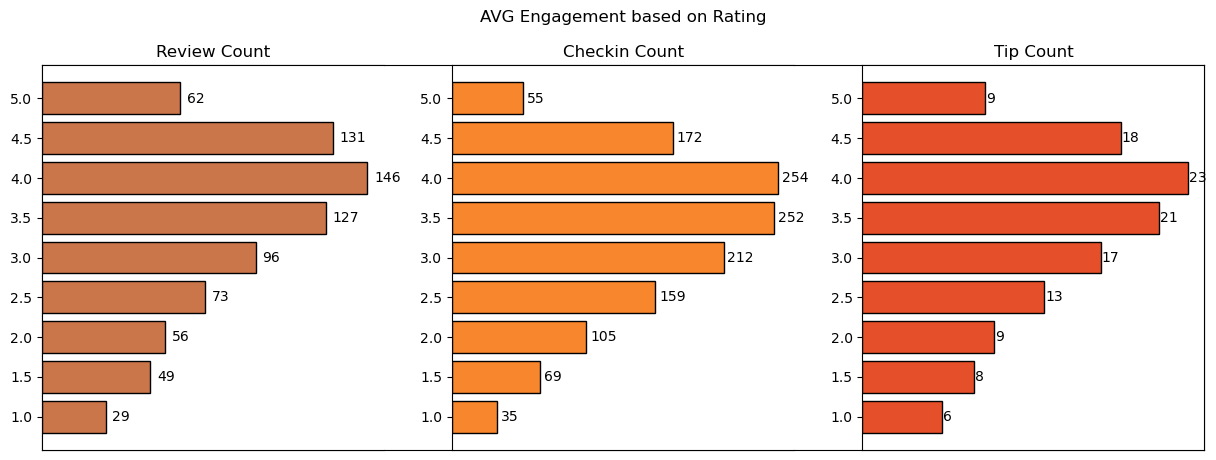

In [72]:
plt.figure(figsize=(15,5))
plt.title('AVG Engagement based on Rating\n\n')
plt.yticks([])
plt.xticks([])

# Review Count
plt.subplot(1,3,1)
plt.title('Review Count')
plt.barh(review_count_df['rating'].astype('str'),
         review_count_df['avg_review_count'],
         edgecolor='k', color='#CB754B')

plt.gca().spines['right'].set_visible(False)

for i, value in enumerate(review_count_df['avg_review_count']):
    plt.text(value+3, i, str(round(value)), color='black', va='center')

plt.xticks([])

# Checkin Count
plt.subplot(1,3,2)
plt.title('Checkin Count')
plt.barh(review_count_df['rating'].astype('str'),
         review_count_df['avg_checkin_count'],
         edgecolor='k', color='#F8862C')

plt.gca().spines['right'].set_visible(False)

for i, value in enumerate(review_count_df['avg_checkin_count']):
    plt.text(value+3, i, str(round(value)), color='black', va='center')

plt.xticks([])

# Tip Count
plt.subplot(1,3,3)
plt.title('Tip Count')
plt.barh(review_count_df['rating'].astype('str'),
         review_count_df['avg_tip_count'],
         edgecolor='k', color='#E54F29')

for i, value in enumerate(review_count_df['avg_tip_count']):
    plt.text(value+0.05, i, str(round(value)), color='black', va='center')

plt.xticks([])
plt.show()

In [73]:
# Is there a correlation between the number of reviews, tips, and check-ins for a business?

engagement_df = pd.read_sql_query(f"""
SELECT 
    b.business_id,
    SUM(b.review_count) AS review_count,
    AVG(b.stars) AS avg_rating,
    SUM(LENGTH(cc.date) - LENGTH(REPLACE(cc.date, ',', '')) + 1) AS checkin_count,
    SUM(tip.tip_count) as tip_count
FROM business b
LEFT JOIN checkin cc ON b.business_id = cc.business_id
LEFT JOIN (
    SELECT business_id, count(business_id) as tip_count 
    FROM tip 
    GROUP BY business_id
) as tip ON b.business_id = tip.business_id
WHERE b.business_id IN {tuple(business_id['business_id'])}
GROUP BY b.business_id
""", conn).dropna()

In [75]:
engagement_df[['review_count','checkin_count','tip_count']].corr()

,review_count,checkin_count,tip_count
review_count,1.000000,0.626884,0.766321
checkin_count,0.626884,1.000000,0.772088
tip_count,0.766321,0.772088,1.000000


<Axes: >

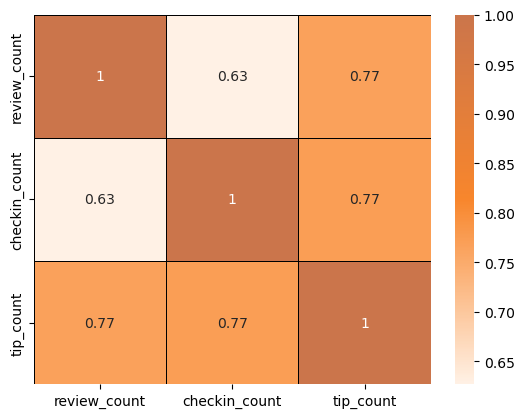

In [76]:
colors = ['#FFF1E5', '#F8862C', '#CB754B']
custom_cmap = LinearSegmentedColormap.from_list("mycmap", colors)
sns.heatmap(
    engagement_df[['review_count','checkin_count','tip_count']].corr(),
    cmap=custom_cmap,
    annot=True,
    linewidths=0.5,
    linecolor='black'
)

In [81]:
# Is there a difference in the user engagement (reviews, tips, and check-ins) between high-rated and low-rated businesses?

pd.read_sql_query(f"""
SELECT 
    b.business_id,
    SUM(b.review_count) AS review_count,
    AVG(b.stars) AS avg_rating,
    SUM(LENGTH(cc.date) - LENGTH(REPLACE(cc.date, ',', '')) + 1) AS checkin_count,
    SUM(tip.tip_count) as tip_count,
    (CASE WHEN b.stars >= 3.5 THEN 'High-Rated' Else 'Low-Rated' END) as category
FROM business b
LEFT JOIN checkin cc ON b.business_id = cc.business_id
LEFT JOIN (
    SELECT business_id, count(business_id) as tip_count 
    FROM tip 
    GROUP BY business_id Order BY tip_count
) as tip ON b.business_id = tip.business_id
WHERE b.business_id IN {tuple(business_id['business_id'])}
GROUP BY b.business_id
""", conn).dropna()

,business_id,review_count,avg_rating,checkin_count,tip_count,category
0,---kPU91CF4Lq2-WlRu9Lw,48,4.5,22.0,8.0,High-Rated
1,--0iUa4sNDFiZFrAdIWhZQ,28,3.0,20.0,12.0,Low-Rated
2,--epgcb7xHGuJ-4PUeSLAw,68,3.0,236.0,12.0,Low-Rated
4,--lqIzK-ZVTtgwiQM63XgQ,30,2.0,42.0,4.0,Low-Rated
5,-09Oc2D14vRnmirPh0vlXw,270,3.0,1000.0,50.0,Low-Rated
...,...,...,...,...,...,...
31530,zzIF9qp2UoHN48EeZH_IDg,38,3.0,12.0,10.0,Low-Rated
31532,zzbZtgPYZS8sTIWQH6DwEw,172,3.0,584.0,34.0,Low-Rated
31533,zziDpuuJw-Km1J4BaGpBKA,12,3.5,40.0,4.0,High-Rated
31534,zzjFdJwXuxBOGe9JeY_EMw,94,4.0,54.0,4.0,High-Rated


In [82]:
# To calculate the success score based on avg rating and total review count
def calculate_success_metric(df):
    success_score = []
    for index, row in df.iterrows():
        score = row['avg_rating'] * np.log(row['review_count'] + 1)
        success_score.append(score)
    return success_score

In [84]:
# How do the success metrics vary across states and cities?
city_df = pd.read_sql_query(f"""
SELECT 
    city, 
    state, 
    latitude, 
    longitude, 
    AVG(stars) as avg_rating, 
    SUM(review_count) as review_count,
    count(*) as restaurant_count
FROM business
WHERE business_id IN {tuple(business_id['business_id'])}
GROUP BY state, city
ORDER BY review_count DESC
LIMIT 10
""", conn)
city_df['success_score'] = calculate_success_metric(city_df)

In [85]:
city_df

,city,state,latitude,longitude,avg_rating,review_count,restaurant_count,success_score
0,Philadelphia,PA,39.955505,-75.155564,3.532156,350974,6002,45.100228
1,Tampa,FL,27.890814,-82.502346,3.571429,208752,3430,43.746096
2,Indianapolis,IN,39.637133,-86.127217,3.412111,185278,3402,41.387597
3,Tucson,AZ,32.338572,-111.010760,3.386187,183226,2838,41.035449
4,Nashville,TN,36.208102,-86.768170,3.493590,174140,2808,42.159316
5,New Orleans,LA,29.963974,-90.042604,3.693676,138478,2024,43.727486
6,Saint Louis,MO,38.583223,-90.407187,3.414303,102980,1622,39.408913
7,Reno,NV,39.476518,-119.784037,3.479626,96786,1178,39.947044
8,Edmonton,AB,53.436403,-113.604288,3.509379,91832,3092,40.104226
9,Boise,ID,43.611192,-116.206275,3.558824,72208,1122,39.813698


In [86]:
# Create a base map
m = folium.Map(
    location=[city_df['latitude'].mean(), city_df['longitude'].mean()],
    zoom_start=4)
# Define a color scale
color_scale = folium.LinearColormap(
    colors=['green', 'yellow', '#E54F29'],
    vmin=city_df['success_score'].min(),
    vmax=city_df['success_score'].max())
# Add markers
for index, row in city_df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color=color_scale(row['success_score']),
        fill=True,
        fill_color=color_scale(row['success_score']),
        fill_opacity=0.7,
        popup=f"Success Score: {row['success_score']}").add_to(m)
# Add color scale
m.add_child(color_scale)

In [112]:
# Are there any patterns in user engagement over time for successful vs less successful businesses? Are there any seasonal trends in user engagement?
high_rated_engagement = pd.read_sql_query(f"""
SELECT review.month_year, review.review_count, tip.tip_count FROM
(
    SELECT strftime('%m-%Y', date) AS month_year, COUNT(*) AS review_count
    FROM review
    WHERE business_id IN {tuple(business_id['business_id'])} AND stars >= 3.5
    GROUP BY month_year
    ORDER BY month_year
) AS review
JOIN
(
    SELECT strftime('%m-%Y', tip.date) AS month_year, COUNT(*) AS tip_count
    FROM tip
    JOIN business b ON tip.business_id = b.business_id
    WHERE tip.business_id IN {tuple(business_id['business_id'])} AND b.stars >= 3.5
    GROUP BY month_year
    ORDER BY month_year
) AS tip
ON review.month_year = tip.month_year
""", conn)

In [88]:
low_rated_engagement = pd.read_sql_query(f"""
SELECT review.month_year, review.review_count, tip.tip_count FROM
(
    SELECT strftime('%m-%Y', date) AS month_year, COUNT(*) AS review_count
    FROM review
    WHERE business_id IN {tuple(business_id['business_id'])} AND stars < 3.5
    GROUP BY month_year
    ORDER BY month_year
) AS review
JOIN
(
    SELECT strftime('%m-%Y', tip.date) AS month_year, COUNT(*) AS tip_count
    FROM tip
    JOIN business b ON tip.business_id = b.business_id
    WHERE tip.business_id IN {tuple(business_id['business_id'])} AND b.stars < 3.5
    GROUP BY month_year
    ORDER BY month_year
) AS tip
ON review.month_year = tip.month_year
""", conn)

In [89]:
high_rated_engagement

,month_year,review_count,tip_count
0,01-2010,1218,158
1,01-2011,2171,1242
2,01-2012,3086,2642
3,01-2013,3801,2460
4,01-2014,4973,2714
...,...,...,...
149,12-2017,10161,2954
150,12-2018,12870,2326
151,12-2019,13756,2322
152,12-2020,11294,1874


In [90]:
low_rated_engagement

,month_year,review_count,tip_count
0,01-2010,613,50
1,01-2011,1103,594
2,01-2012,1748,1076
3,01-2013,2196,1096
4,01-2014,2769,1214
...,...,...,...
149,12-2017,5970,882
150,12-2018,7574,676
151,12-2019,7591,550
152,12-2020,5014,296


In [91]:
time_rating = pd.read_sql_query(f"""
SELECT strftime('%m-%Y', date) AS month_year, AVG(stars) as avg_rating
FROM review
WHERE business_id IN {tuple(business_id['business_id'])}
GROUP BY month_year
ORDER BY month_year
""", conn)

In [92]:
time_rating

,month_year,avg_rating
0,01-2006,4.000000
1,01-2007,3.897436
2,01-2008,3.603960
3,01-2009,3.690661
4,01-2010,3.724194
...,...,...
198,12-2017,3.613415
199,12-2018,3.608687
200,12-2019,3.665246
201,12-2020,3.833701


In [93]:
time_rating = pd.read_sql_query(f"""
SELECT strftime('%m-%Y', date) AS month_year, AVG(stars) as avg_rating
FROM review
WHERE business_id IN {tuple(business_id['business_id'])}
GROUP BY month_year
ORDER BY month_year
""", conn)

In [94]:
time_rating['month_year'] = pd.to_datetime(time_rating['month_year'])
time_rating.sort_values('month_year', inplace=True)
time_rating = time_rating[time_rating['month_year'] > '2017']

high_rated_engagement['month_year'] = pd.to_datetime(high_rated_engagement['month_year'])
high_rated_engagement.sort_values('month_year', inplace=True)
high_rated_engagement = high_rated_engagement[high_rated_engagement['month_year'] > '2017']

low_rated_engagement['month_year'] = pd.to_datetime(low_rated_engagement['month_year'])
low_rated_engagement.sort_values('month_year', inplace=True)
low_rated_engagement = low_rated_engagement[low_rated_engagement['month_year'] > '2017']

In [95]:
high_rated_engagement['avg_rating'] = time_rating['avg_rating'].values

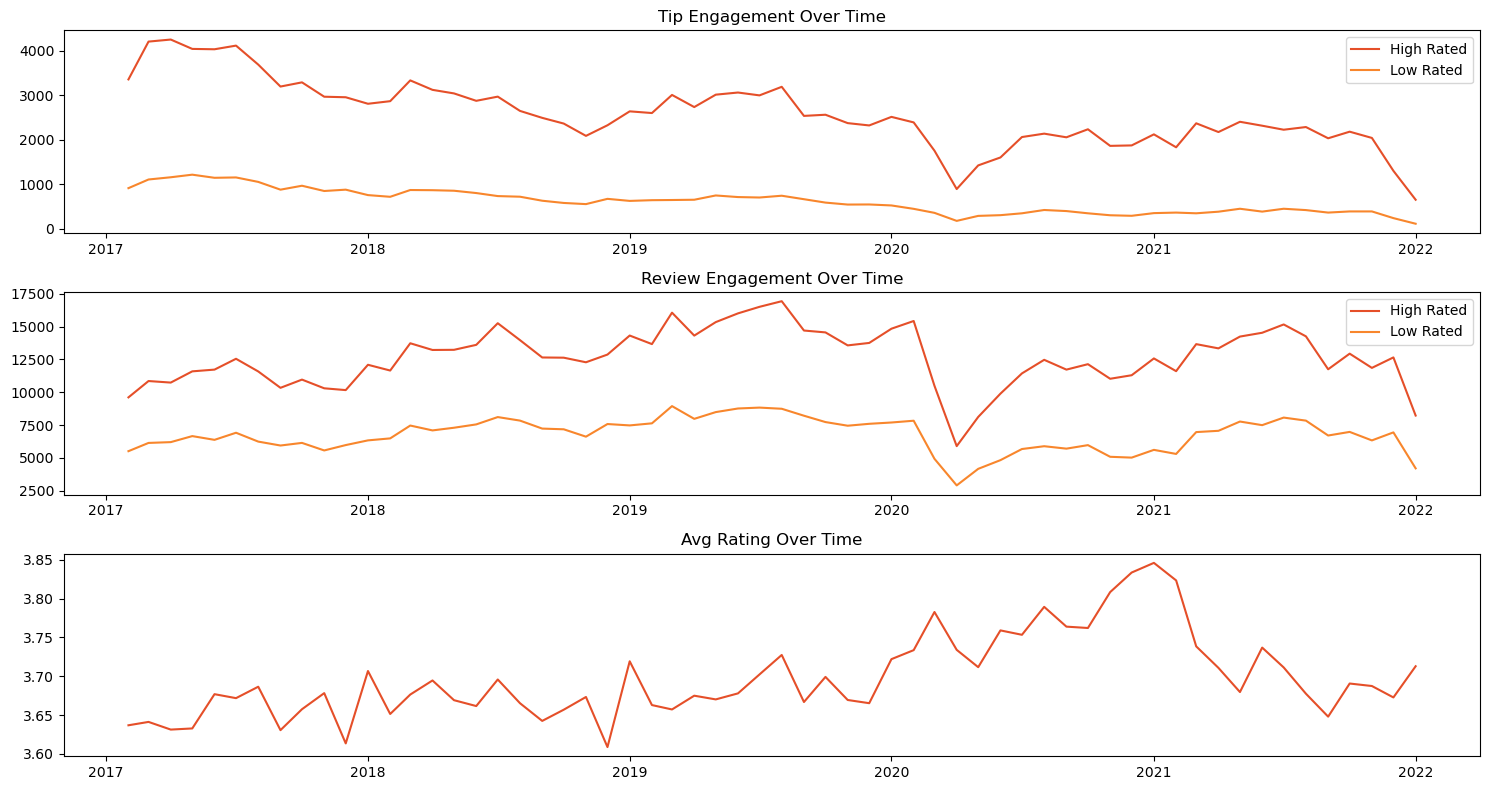

In [96]:
plt.figure(figsize=(15,8))

# Tip Engagement
plt.subplot(3,1,1)
plt.title('Tip Engagement Over Time')
plt.plot(high_rated_engagement['month_year'], high_rated_engagement['tip_count'],
         label='High Rated', color='#E54F29')
plt.plot(low_rated_engagement['month_year'], low_rated_engagement['tip_count'],
         label='Low Rated', color='#F8862C')
plt.legend()

# Review Engagement
plt.subplot(3,1,2)
plt.title('Review Engagement Over Time')
plt.plot(high_rated_engagement['month_year'], high_rated_engagement['review_count'],
         label='High Rated', color='#E54F29')
plt.plot(low_rated_engagement['month_year'], low_rated_engagement['review_count'],
         label='Low Rated', color='#F8862C')
plt.legend()

# Avg Rating Trend
plt.subplot(3,1,3)
plt.title('Avg Rating Over Time')
plt.plot(time_rating['month_year'], time_rating['avg_rating'], color='#E54F29')

plt.tight_layout()
plt.show()

In [97]:
tip_high_rated = high_rated_engagement[['month_year','tip_count']].set_index('month_year')
review_high_rated = high_rated_engagement[['month_year','review_count']].set_index('month_year')
rating_df = time_rating[['month_year','avg_rating']].set_index('month_year')

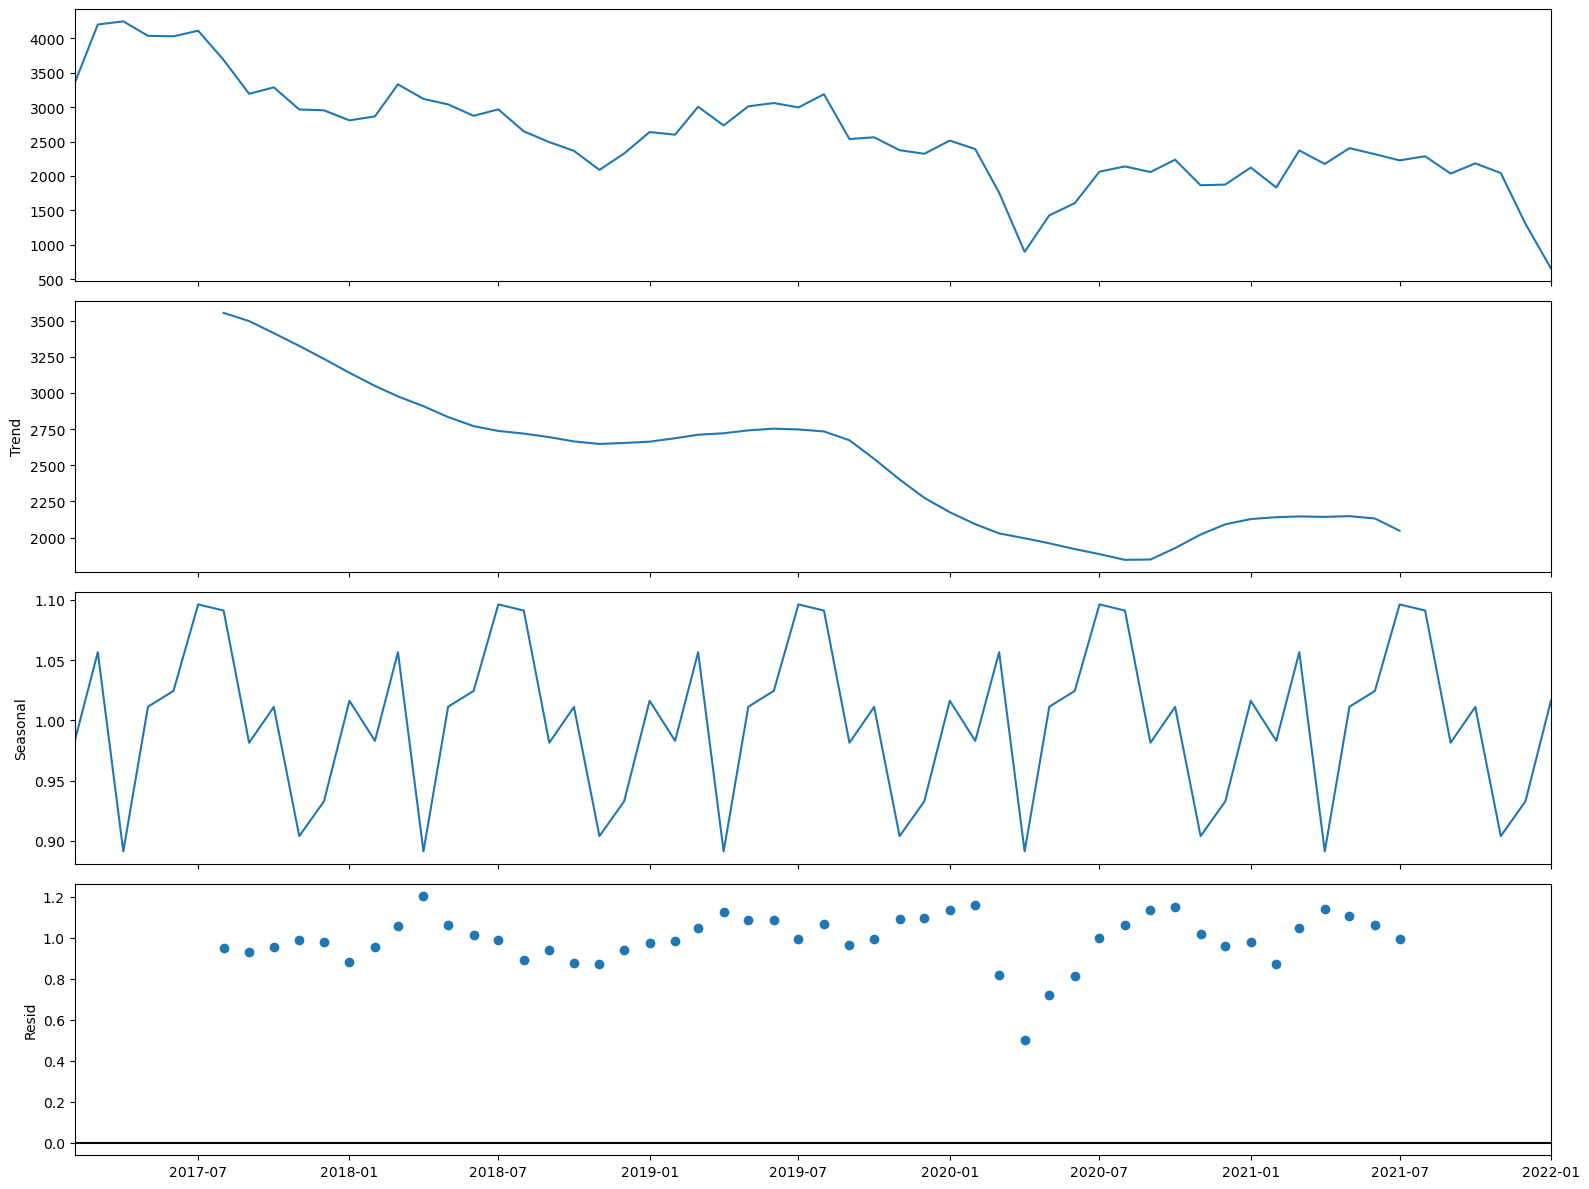

In [98]:
from statsmodels.tsa.seasonal import seasonal_decompose

multiplicative_decomposition = seasonal_decompose(
    tip_high_rated,
    model='multiplicative',
    period=12
)

plt.rcParams.update({'figure.figsize': (16,12)})
multiplicative_decomposition.plot()
plt.show()

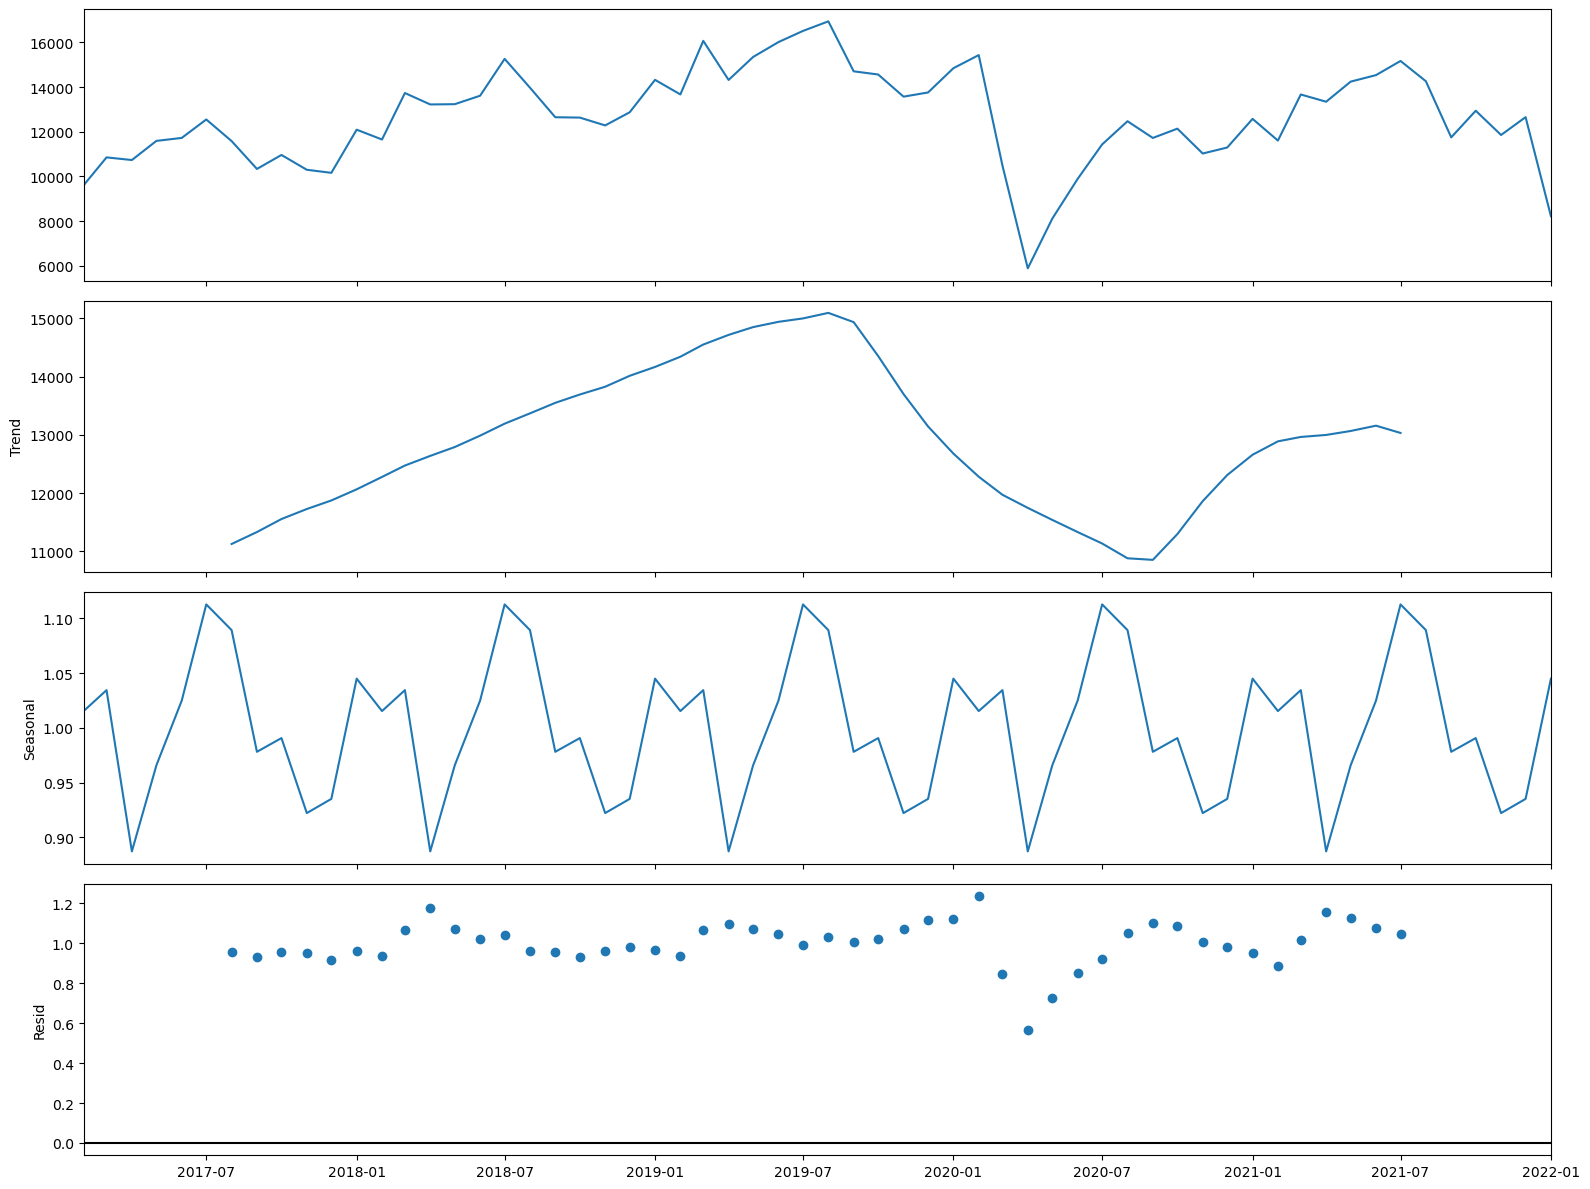

In [99]:
multiplicative_decomposition = seasonal_decompose(
    review_high_rated,
    model='multiplicative',
    period=12
)

plt.rcParams.update({'figure.figsize': (16,12)})
multiplicative_decomposition.plot()
plt.show()

In [100]:
# How does the sentiment of reviews and tips (useful, funny, cool) correlate with success metrics?
sentiment_df = pd.read_sql_query(f"""
SELECT 
    b.business_id,
    AVG(b.stars) as avg_rating,
    SUM(b.review_count) as review_count,
    SUM(s.useful_count) as useful_count,
    SUM(s.funny_count) as funny_count,
    SUM(s.cool_count) as cool_count
FROM
(
    SELECT 
        business_id,
        SUM(useful) as useful_count,
        SUM(funny) as funny_count,
        SUM(cool) as cool_count
    FROM review
    GROUP BY business_id
) as s
JOIN business as b ON b.business_id = s.business_id
WHERE b.business_id IN {tuple(business_id['business_id'])}
GROUP BY b.business_id
ORDER BY review_count
""", conn)

sentiment_df = remove_outliers(sentiment_df, 'review_count')
sentiment_df = remove_outliers(sentiment_df, 'useful_count')
sentiment_df = remove_outliers(sentiment_df, 'funny_count')
sentiment_df = remove_outliers(sentiment_df, 'cool_count')

In [102]:
sentiment_df['success_score'] = calculate_success_metric(sentiment_df)

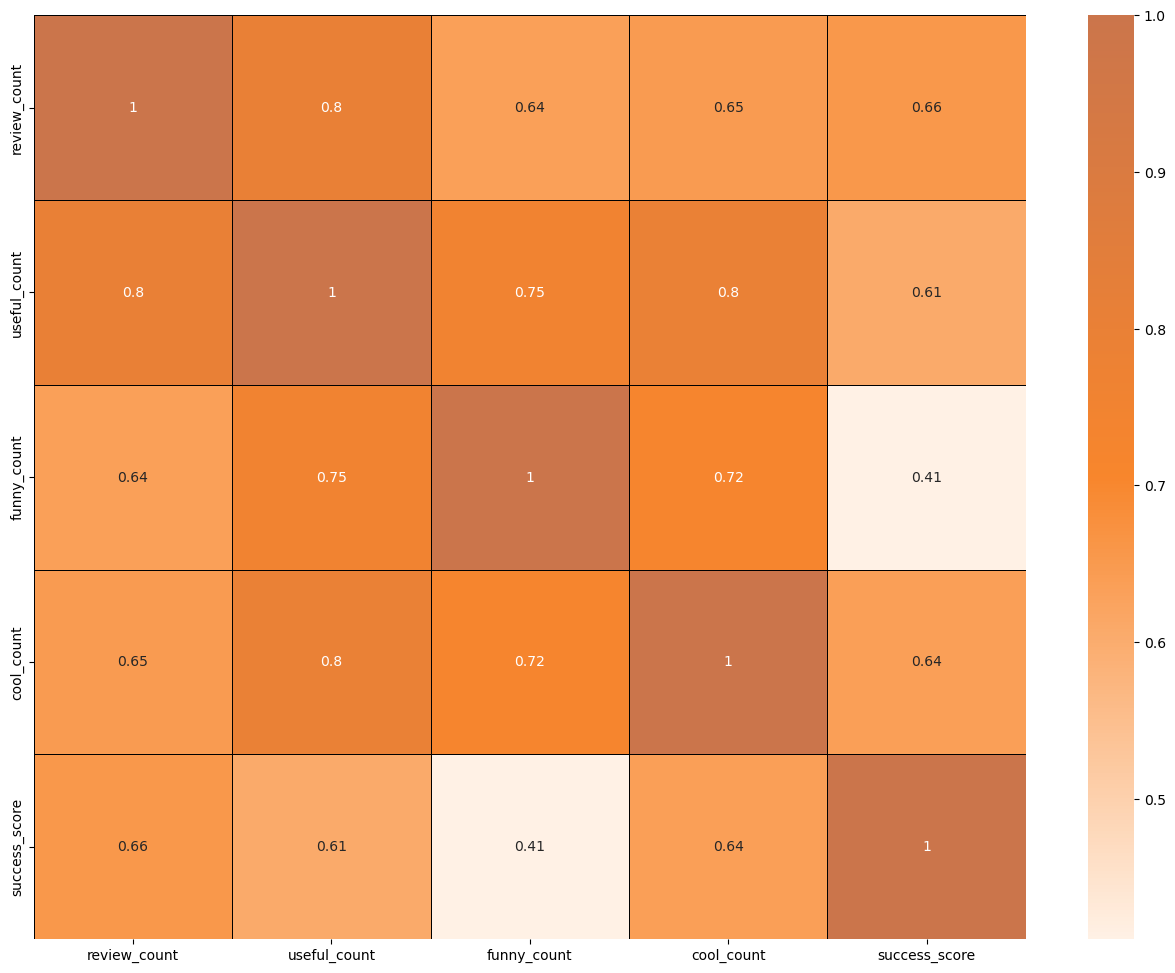

In [104]:
sns.heatmap(sentiment_df.iloc[:,2:].corr(),
           cmap = custom_cmap, annot = True,
           linewidth = 0.5, linecolor = 'black')
plt.show()

In [105]:
# Is there any difference in engagement of elite users and non-elite users?

elite_df = pd.read_sql_query("""
SELECT 
    elite,
    COUNT(*) AS num_users,
    SUM(review_count) AS total_review_count
FROM
(
    SELECT 
        CASE 
            WHEN elite = '' THEN 'Not Elite'
            ELSE 'Elite'
        END AS elite,
        u.review_count
    FROM user u
) AS user_elite
GROUP BY elite
""", conn)

In [106]:
elite_df

,elite,num_users,total_review_count
0,Elite,91198,20484441
1,Not Elite,1896699,26021235


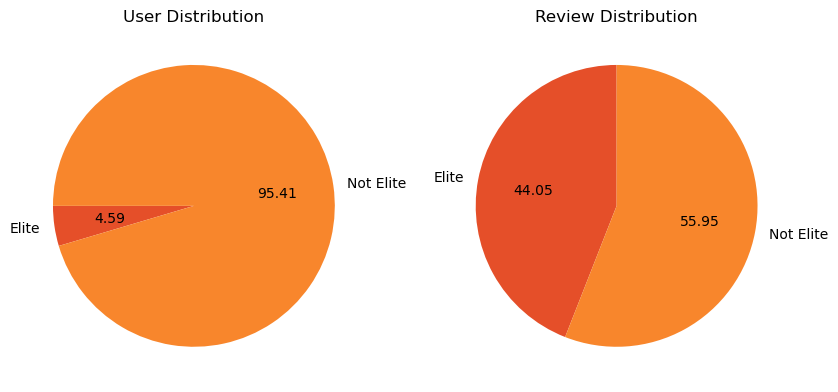

In [107]:
plt.figure(figsize=(10,6))

# User Distribution
plt.subplot(1,2,1)
plt.title('User Distribution')
plt.pie(elite_df['num_users'],
        labels=elite_df['elite'],
        autopct='%.2f',
        startangle=180,
        colors=['#E54F29','#F8862C'])

# Review Distribution
plt.subplot(1,2,2)
plt.title('Review Distribution')
plt.pie(elite_df['total_review_count'],
        labels=elite_df['elite'],
        autopct='%.2f',
        startangle=90,
        colors=['#E54F29','#F8862C'])

plt.show()

In [110]:
# What are the busiest hours for restaurants?

review_engagement = pd.read_sql_query("""
SELECT 
    CAST(strftime('%H', date) AS INTEGER) as hour,
    COUNT(*) AS review_count
FROM review
GROUP BY hour
""", conn)

tip_engagement = pd.read_sql_query("""
SELECT 
    CAST(strftime('%H', date) AS INTEGER) as hour,
    COUNT(*) AS tip_count
FROM tip
GROUP BY hour
""", conn)

checkin = pd.read_sql_query("SELECT date FROM checkin", conn)

checkin_engagement = []
for i in checkin['date']:
    checkin_engagement.extend([
        datetime.strptime(j.strip(), "%Y-%m-%d %H:%M:%S").strftime("%H")
        for j in i.split(',')
    ])

checkin_engagement = pd.DataFrame(checkin_engagement)\
                        .astype('int')\
                        .groupby(0)[0].count()

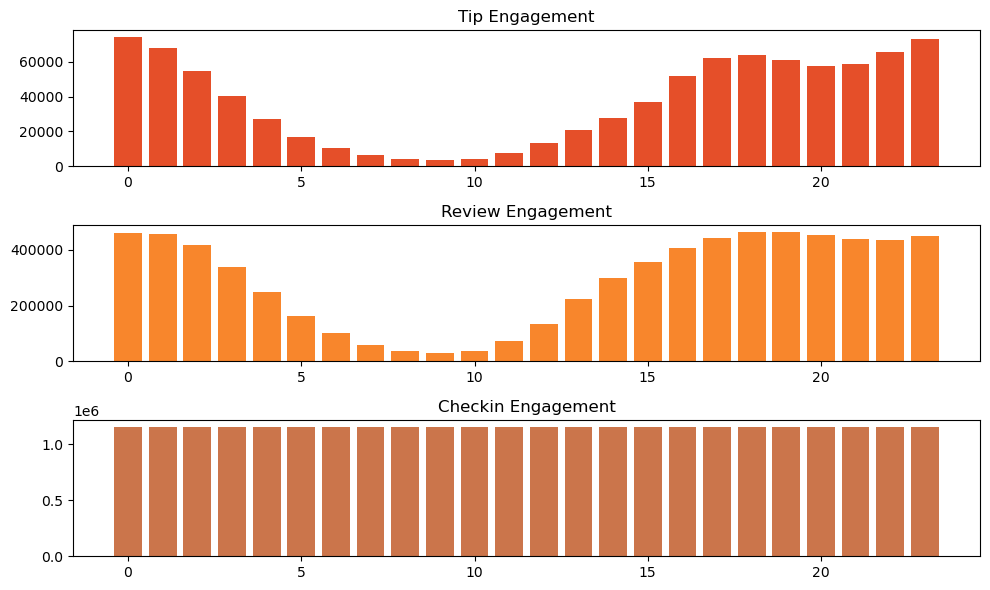

In [109]:
plt.figure(figsize=(10,6))

# Tip Engagement
plt.subplot(3,1,1)
plt.title('Tip Engagement')
plt.bar(tip_engagement['hour'], tip_engagement['tip_count'], color='#E54F29')

# Review Engagement
plt.subplot(3,1,2)
plt.title('Review Engagement')
plt.bar(review_engagement['hour'], review_engagement['review_count'], color='#F8862C')

# Check-in Engagement
plt.subplot(3,1,3)
plt.title('Checkin Engagement')
plt.bar(checkin_engagement.index, checkin_engagement[0], color='#CB754B')

plt.tight_layout()
plt.show()